In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import json
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
tqdm.pandas()

# Reproducibility
RANDOM_STATE = 42

# Target & features setup
TARGET_COL = "economically_disadvantaged"

df_path = "../data/persuade/persuade_full_cleaned.csv"

EMB_DIR = "../embeddings/embeddings_full.npy"

SAVE_DIR = ""

MODEL_DIR = "../model/run_01/"

In [2]:
df = pd.read_csv(df_path)
y = df['economically_disadvantaged'].copy()

In [3]:
emb_x = np.load(EMB_DIR)

In [4]:
assert emb_x.shape[0] == df.shape[0]

### Using Embeddings to predict SES status

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    emb_x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [6]:
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [7]:
y_prob = model.predict_proba(X_test)[:, 1]
y_hat  = model.predict(X_test)

In [8]:
print("AUC:", roc_auc_score(y_test, y_prob))
print("Accuracy:", accuracy_score(y_test, y_hat))

AUC: 0.7051640013087177
Accuracy: 0.6507707129094412


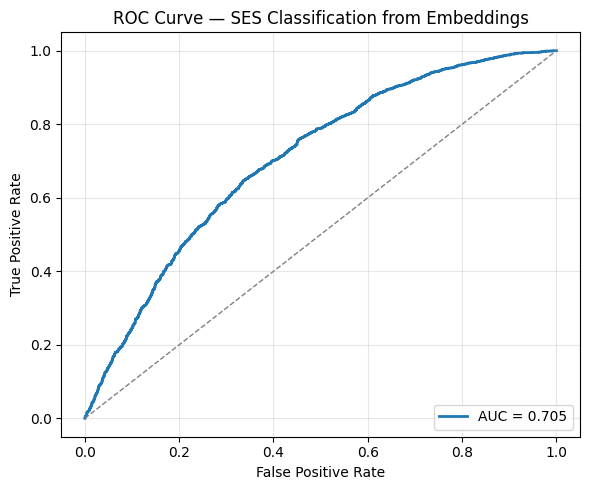

In [9]:
# Compute ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — SES Classification from Embeddings")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

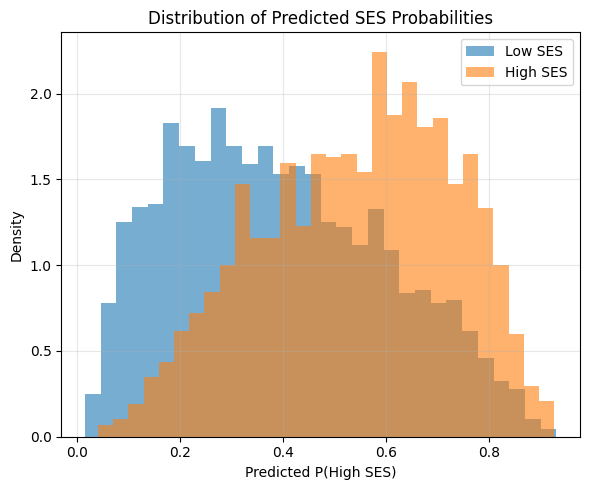

In [10]:
# Split predictions by true SES
prob_low  = y_prob[y_test == 0]
prob_high = y_prob[y_test == 1]

plt.figure(figsize=(6, 5))

plt.hist(
    prob_low,
    bins=30,
    alpha=0.6,
    density=True,
    label="Low SES",
)
plt.hist(
    prob_high,
    bins=30,
    alpha=0.6,
    density=True,
    label="High SES",
)

plt.xlabel("Predicted P(High SES)")
plt.ylabel("Density")
plt.title("Distribution of Predicted SES Probabilities")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
